In [69]:
import pandas as pd

In [70]:
df = pd.read_csv('99 dataset finally - Sheet1.csv')
df= df.drop(columns=['exp no','Source Report', 'Force', 'Area'], axis=1)

In [71]:
df.columns

Index(['Run', 'Infill Density (%)', 'Nozzle Temperature (C)', 'Infill Pattern',
       'Tensile Stress'],
      dtype='object')

In [72]:
df

,Run,Infill Density (%),Nozzle Temperature (C),Infill Pattern,Tensile Stress
0,1,60.0000,260.000,Triangle-Hexa,12.889417
1,1,60.0000,260.000,Triangle-Hexa,14.322583
2,1,60.0000,260.000,Triangle-Hexa,16.093917
3,2,45.8579,254.142,Grid,11.980667
4,2,45.8579,254.142,Grid,12.426083
...,...,...,...,...,...
94,32,60.0000,260.000,Grid,14.814250
95,32,60.0000,260.000,Grid,15.769833
96,33,60.0000,220.000,Triangle-Hexa,12.785750
97,33,60.0000,220.000,Triangle-Hexa,12.219083


In [73]:
# one-hot encode the 'Infill Pattern' column
df_encoded = pd.get_dummies(df, columns=['Infill Pattern'])
df_encoded['Infill Pattern_Grid'] = df_encoded['Infill Pattern_Grid'].astype(int)
df_encoded['Infill Pattern_Triangle'] = df_encoded['Infill Pattern_Triangle'].astype(int)
df_encoded['Infill Pattern_Triangle-Hexa'] = df_encoded['Infill Pattern_Triangle-Hexa'].astype(int)



In [74]:
df_encoded[['Infill Pattern_Grid', 'Infill Pattern_Triangle', 'Infill Pattern_Triangle-Hexa']].head(10)

,Infill Pattern_Grid,Infill Pattern_Triangle,Infill Pattern_Triangle-Hexa
0,0,0,1
1,0,0,1
2,0,0,1
3,1,0,0
4,1,0,0
5,1,0,0
6,0,1,0
7,0,1,0
8,0,1,0
9,1,0,0


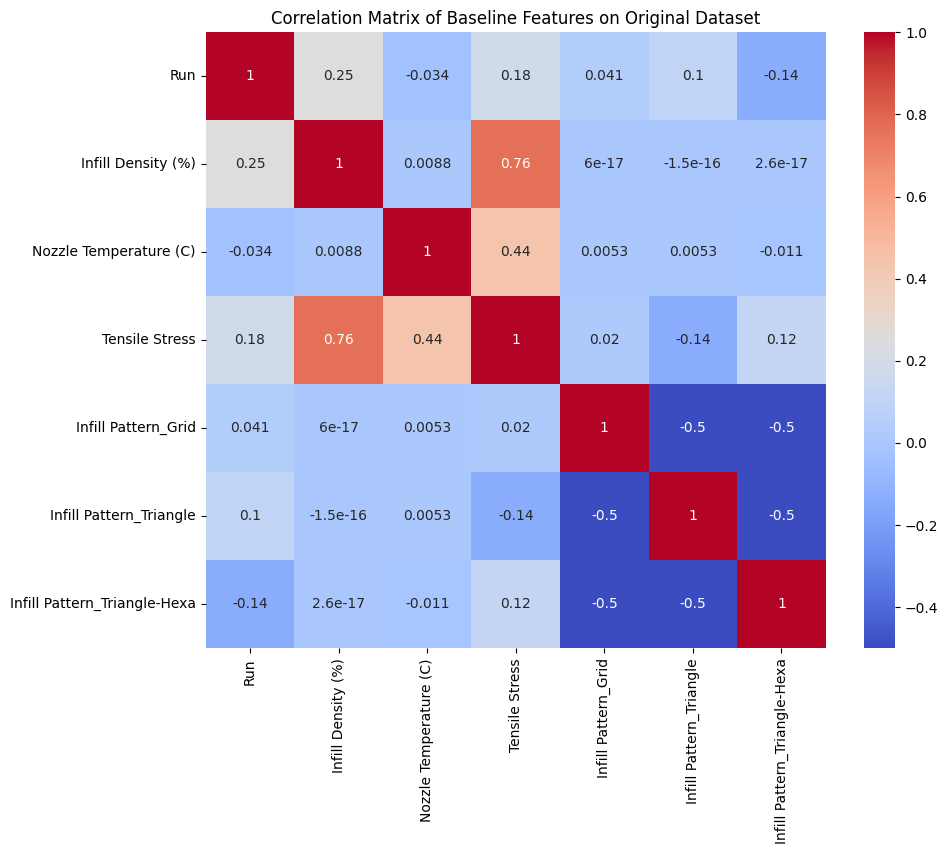

In [75]:
from matplotlib import pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8))
correlation_matrix = df_encoded.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Baseline Features on Original Dataset')
plt.show()

## Effective Area ($A_{eff}$)

In [76]:
# Create a mapping for the Geometry Factor
# Note: Since your data is one-hot encoded, we multiply by the column indicator
df_encoded['Effective Load-Bearing Area (Aeff)'] = df_encoded['Infill Density (%)'] * (
    (df_encoded['Infill Pattern_Triangle-Hexa'] * 1.0) +
    (df_encoded['Infill Pattern_Triangle'] * 0.85) +
    (df_encoded['Infill Pattern_Grid'] * 0.70)
)

## polymer difusin rate

In [77]:
import numpy as np

# 1. Define Constants
Ea = 68000  # Activation Energy for PA6 (J/mol)
R = 8.314    # Gas Constant
T_kelvin = df_encoded['Nozzle Temperature (C)'] + 273.15

# 2. Calculate Polymer Diffusion Rate
# We can set D0 = 1 for relative comparison
df_encoded['Diffusion Rate'] = np.exp(-Ea / (R * T_kelvin))

# 3. Normalize it so it stays on a 0-1 scale like your other features
df_encoded['Diffusion_Rate_Normalized'] = (df_encoded['Diffusion Rate'] - df_encoded['Diffusion Rate'].min()) / \
                                          (df_encoded['Diffusion Rate'].max() - df_encoded['Diffusion Rate'].min())

In [78]:
df_encoded

,Run,Infill Density (%),Nozzle Temperature (C),Tensile Stress,Infill Pattern_Grid,Infill Pattern_Triangle,Infill Pattern_Triangle-Hexa,Effective Load-Bearing Area (Aeff),Diffusion Rate,Diffusion_Rate_Normalized
0,1,60.0000,260.000,12.889417,0,0,1,60.00000,2.175468e-07,1.000000
1,1,60.0000,260.000,14.322583,0,0,1,60.00000,2.175468e-07,1.000000
2,1,60.0000,260.000,16.093917,0,0,1,60.00000,2.175468e-07,1.000000
3,2,45.8579,254.142,11.980667,1,0,0,32.10053,1.834575e-07,0.779875
4,2,45.8579,254.142,12.426083,1,0,0,32.10053,1.834575e-07,0.779875
...,...,...,...,...,...,...,...,...,...,...
94,32,60.0000,260.000,14.814250,1,0,0,42.00000,2.175468e-07,1.000000
95,32,60.0000,260.000,15.769833,1,0,0,42.00000,2.175468e-07,1.000000
96,33,60.0000,220.000,12.785750,0,0,1,60.00000,6.268352e-08,0.000000
97,33,60.0000,220.000,12.219083,0,0,1,60.00000,6.268352e-08,0.000000


# physics augmented corrilation

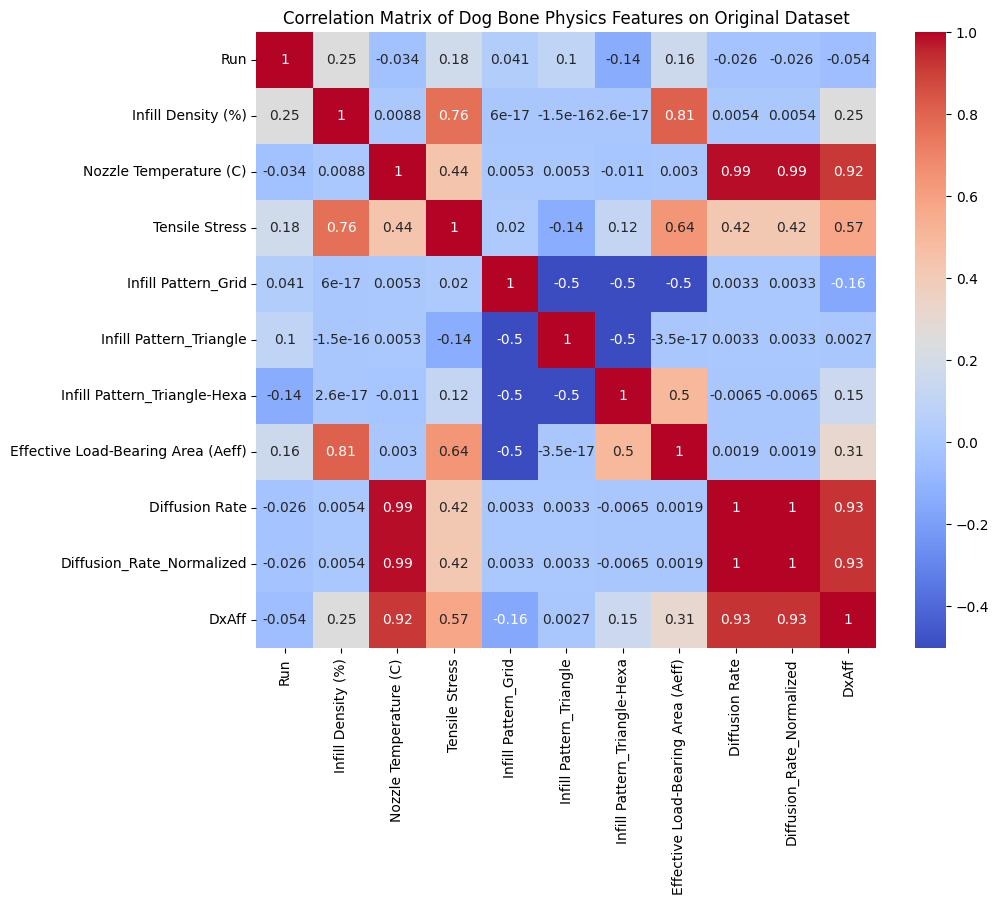

In [79]:
df_encoded['DxAff'] = df_encoded['Effective Load-Bearing Area (Aeff)'] * df_encoded['Diffusion_Rate_Normalized']

from matplotlib import pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8))
correlation_matrix = df_encoded.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Dog Bone Physics Features on Original Dataset')
plt.show()

# Features defination

In [80]:
# Physics-Augmented Features

FEATURES_PHYSICS = [
    # 'Infill Density (%)', ## comment this has been droped for using IVF in augmneted results
    'Infill Pattern_Grid', 
    'Infill Pattern_Triangle', 
    'Infill Pattern_Triangle-Hexa', 
    'Effective Load-Bearing Area (Aeff)',
    # 'Diffusion_Rate_Normalized',
    'DxAff'
]


# Baseline Features (Standard Engineering)
FEATURES_BASE = [
    'Infill Density (%)', 
    'Nozzle Temperature (C)', 
    'Infill Pattern_Grid', 
    'Infill Pattern_Triangle', 
    'Infill Pattern_Triangle-Hexa'
]

# Defining the target
target = 'Tensile Stress'


# RF Baseline

In [81]:
from sklearn.model_selection import GroupShuffleSplit

# 1. Define your groups (e.g., use 'Infill Pattern' or a 'Batch_ID' column)
# For this example, let's assume you want to group by 'Infill Pattern'


X_base = df_encoded[FEATURES_BASE]
y = df_encoded[target]

groups = df['Run'] 
# 2. Initialize the splitter
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# 3. Perform the split
# .split() returns indices for train and test
train_idx, test_idx = next(gss.split(X_base, y, groups=groups))

X_train_base = X_base.iloc[train_idx]
X_test = X_base.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

# Print shapes to verify
print(f'Shape of X_train: {X_train_base.shape}')
print(f'Shape of X_test: {X_test.shape}')

Shape of X_train: (78, 5)
Shape of X_test: (21, 5)


In [82]:
# Check unique groups in train vs test
train_groups = set(groups.iloc[train_idx])
test_groups = set(groups.iloc[test_idx])

# This should be empty (no overlap)
overlap = train_groups.intersection(test_groups)
print(f"Overlapping groups: {overlap}")

Overlapping groups: set()


In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import GroupKFold
from sklearn.model_selection import cross_validate

rf_base = RandomForestRegressor(
    n_estimators=500,       # More trees for better variance reduction
    max_depth=None,         # Let trees grow, but control them with samples_leaf
    min_samples_split=5,    # Requires more data to create a branch
    min_samples_leaf=2,     # Lower this (from 7) to capture more detail
    max_features='sqrt',    # CRITICAL: Forces trees to be different; helps generalization
    bootstrap=True,
    oob_score=True,         # Use Out-Of-Bag score as an extra validation metric
    random_state=42,
    n_jobs=-1
)
rf_base.fit(X_train_base, y_train)

y_pred = rf_base.predict(X_test)

rf_r2_base  = r2_score(y_test, y_pred)
rf_mse_base = mean_squared_error(y_test, y_pred)
rf_rmse_base = np.sqrt(rf_mse_base)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()
rf_acc_2_5_base = tolerance_accuracy(y_test.values, y_pred, 0.25)
rf_acc_05_base = tolerance_accuracy(y_test.values, y_pred, 0.5)
rf_acc_10_base = tolerance_accuracy(y_test.values, y_pred, 1.0)
rf_acc_20_base = tolerance_accuracy(y_test.values, y_pred, 2.0)
rf_acc_30_base = tolerance_accuracy(y_test.values, y_pred, 3.0)
print(f"=== Random Forest Prediction (Test) for BaseLine Features ===")
print(f"R²          : {rf_r2_base:.4f}")
print(f"RMSE        : {rf_rmse_base:.3f} MPa")
print(f"MSE         : {rf_mse_base:.4f} MPa")
print("Accuracy (Relative to Target Range 8.0-19.0 MPa):")
print(f"  High Precision (±0.25 MPa): {rf_acc_2_5_base* 100:5.2f}%")
print(f"  Engineering    (±0.50 MPa): {rf_acc_05_base * 100:5.2f}%")
print(f"  Acceptable     (±1.00 MPa): {rf_acc_10_base * 100:5.2f}%")
print(f"  Upper Bound    (±2.00 MPa): {rf_acc_20_base * 100:5.2f}%")

n_splits = 5 
gkf = GroupKFold(n_splits=n_splits)

# 2. Define the groups to be used during CV
# Using the same 'groups' variable we defined for the initial split
groups_cv = df['Run']

scoring_metrics = {
    'r2': 'r2',
    'mse': 'neg_mean_squared_error'
}

# 2. Run cross-validation
cv_results = cross_validate(
    rf_base, 
    X_base, 
    y, 
    cv=gkf, 
    groups=groups_cv, 
    scoring=scoring_metrics, 
    n_jobs=-1
)

# 3. Extract and process the results
# Note: sklearn returns negative MSE because it follows the "higher is better" rule
cv_mse_scores = -cv_results['test_mse'] 
cv_rmse_scores = np.sqrt(cv_mse_scores)
cv_r2_scores = cv_results['test_r2']

print("\n=== GroupKFold CV Evaluation Matrix for BaseLine Features ===")
print(f"Mean R²   : {cv_r2_scores.mean():.4f}  (±{cv_r2_scores.std():.4f})")
print(f"Mean MSE  : {cv_mse_scores.mean():.4f} MPa²")
print(f"Mean RMSE : {cv_rmse_scores.mean():.4f} MPa")
print(f"R² Scores : {np.round(cv_r2_scores, 4)}")

fi = pd.DataFrame({
    'feature'   : FEATURES_BASE,
    'importance': rf_base.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))


=== Random Forest Prediction (Test) for BaseLine Features ===
R²          : 0.3535
RMSE        : 2.196 MPa
MSE         : 4.8231 MPa
Accuracy (Relative to Target Range 8.0-19.0 MPa):
  High Precision (±0.25 MPa): 14.29%
  Engineering    (±0.50 MPa): 14.29%
  Acceptable     (±1.00 MPa): 28.57%
  Upper Bound    (±2.00 MPa): 80.95%

=== GroupKFold CV Evaluation Matrix for BaseLine Features ===
Mean R²   : 0.5686  (±0.1021)
Mean MSE  : 2.8639 MPa²
Mean RMSE : 1.5713 MPa
R² Scores : [0.6853 0.5857 0.67   0.4629 0.4391]

=== Feature Importances (Top 10) ===
                     feature  importance
          Infill Density (%)    0.698672
      Nozzle Temperature (C)    0.171671
     Infill Pattern_Triangle    0.058640
Infill Pattern_Triangle-Hexa    0.048082
         Infill Pattern_Grid    0.022935


# rf physics

In [84]:
import pandas as pd
from sklearn.model_selection import train_test_split

X_physics = df_encoded[FEATURES_PHYSICS]
y = df_encoded[target]

# physics features
groups = df['Run'] 
# 2. Initialize the splitter
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# 3. Perform the split
# .split() returns indices for train and test
train_idx, test_idx = next(gss.split(X_physics, y, groups=groups))

X_train_physics = X_physics.iloc[train_idx]
X_test = X_physics.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

# Print shapes to verify
print(f'Shape of X_train: {X_train_physics.shape}')
print(f'Shape of X_test: {X_test.shape}')

Shape of X_train: (78, 5)
Shape of X_test: (21, 5)


In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

rf_physics = RandomForestRegressor(
    n_estimators=500,       # More trees for better variance reduction
    max_depth=None,         # Let trees grow, but control them with samples_leaf
    min_samples_split=5,    # Requires more data to create a branch
    min_samples_leaf=2,     # Lower this (from 7) to capture more detail
    max_features='sqrt',    # CRITICAL: Forces trees to be different; helps generalization
    bootstrap=True,
    oob_score=True,         # Use Out-Of-Bag score as an extra validation metric
    random_state=42,
    n_jobs=-1
)
rf_physics.fit(X_train_physics, y_train)

y_pred = rf_physics.predict(X_test)

rf_r2_physics  = r2_score(y_test, y_pred)
rf_mse_physics = mean_squared_error(y_test, y_pred)
rf_rmse_physics = np.sqrt(rf_mse_physics)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()
rf_acc_2_5_physics = tolerance_accuracy(y_test.values, y_pred, 0.25)
rf_acc_05_physics = tolerance_accuracy(y_test.values, y_pred, 0.5)
rf_acc_10_physics = tolerance_accuracy(y_test.values, y_pred, 1.0)
rf_acc_20_physics = tolerance_accuracy(y_test.values, y_pred, 2.0)
rf_acc_30_physics = tolerance_accuracy(y_test.values, y_pred, 3.0)

print(f"=== Random Forest Prediction (Test) for Physics Augmented Features ===")
print(f"R²          : {rf_r2_physics:.4f}")
print(f"RMSE        : {rf_rmse_physics:.3f} MPa")
print(f"MSE         : {rf_mse_physics:.4f} MPa")
print("Accuracy (Relative to Target Range 8.0-19.0 MPa):")
print(f"  High Precision (±0.25 MPa): { rf_acc_2_5_physics* 100:5.2f}%")
print(f"  Engineering    (±0.50 MPa): {rf_acc_05_physics * 100:5.2f}%")
print(f"  Acceptable     (±1.00 MPa): {rf_acc_10_physics * 100:5.2f}%")
print(f"  Upper Bound    (±2.00 MPa): {rf_acc_20_physics * 100:5.2f}%")


n_splits = 5 
gkf = GroupKFold(n_splits=n_splits)

# 2. Define the groups to be used during CV
# Using the same 'groups' variable we defined for the initial split
groups_cv = df['Run']

scoring_metrics = {
    'r2': 'r2',
    'mse': 'neg_mean_squared_error'
}

# 2. Run cross-validation
cv_results = cross_validate(
    rf_base, 
    X_base, 
    y, 
    cv=gkf, 
    groups=groups_cv, 
    scoring=scoring_metrics, 
    n_jobs=-1
)

# 3. Extract and process the results
# Note: sklearn returns negative MSE because it follows the "higher is better" rule
cv_mse_scores = -cv_results['test_mse'] 
cv_rmse_scores = np.sqrt(cv_mse_scores)
cv_r2_scores = cv_results['test_r2']

print("\n=== GroupKFold CV Evaluation Matrix for Physics Features ===")
print(f"Mean R²   : {cv_r2_scores.mean():.4f}  (±{cv_r2_scores.std():.4f})")
print(f"Mean MSE  : {cv_mse_scores.mean():.4f} MPa²")
print(f"Mean RMSE : {cv_rmse_scores.mean():.4f} MPa")
print(f"R² Scores : {np.round(cv_r2_scores, 4)}")

fi = pd.DataFrame({
    'feature'   : FEATURES_PHYSICS,
    'importance': rf_physics.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))

=== Random Forest Prediction (Test) for Physics Augmented Features ===
R²          : 0.3458
RMSE        : 2.209 MPa
MSE         : 4.8809 MPa
Accuracy (Relative to Target Range 8.0-19.0 MPa):
  High Precision (±0.25 MPa):  9.52%
  Engineering    (±0.50 MPa): 28.57%
  Acceptable     (±1.00 MPa): 57.14%
  Upper Bound    (±2.00 MPa): 66.67%

=== GroupKFold CV Evaluation Matrix for Physics Features ===
Mean R²   : 0.5686  (±0.1021)
Mean MSE  : 2.8639 MPa²
Mean RMSE : 1.5713 MPa
R² Scores : [0.6853 0.5857 0.67   0.4629 0.4391]

=== Feature Importances (Top 10) ===
                           feature  importance
Effective Load-Bearing Area (Aeff)    0.494676
                             DxAff    0.411577
           Infill Pattern_Triangle    0.039093
      Infill Pattern_Triangle-Hexa    0.030210
               Infill Pattern_Grid    0.024444
